# AdaBoost (Adaptive Boosting)

---

## 1. What is AdaBoost?

**AdaBoost** is an ensemble learning algorithm that combines multiple **weak learners** to form a **strong classifier**.

- Proposed by **Freund and Schapire (1996)**
- Commonly used with **decision stumps**
- Mainly for **binary classification**

### Core Idea
Focus more on the **mistakes made by previous models** by increasing their importance (weights).

---

## 2. Weak Learner Assumption

A weak learner performs **slightly better than random guessing**.

For binary classification:

$$
\text{Error} < 0.5
$$

---

## 3. Problem Setup (Notation)

Given a training dataset:

$$
\{(x_1, y_1), (x_2, y_2), \ldots, (x_N, y_N)\}
$$

Where:

$$
x_i \in \mathbb{R}^d
$$

$$
y_i \in \{-1, +1\}
$$

---

## 4. Initialize Sample Weights

Initially, all samples have equal weights:

$$
w_i^{(1)} = \frac{1}{N}, \quad i = 1, 2, \ldots, N
$$

Weights represent the **importance** of each sample.

---

## 5. AdaBoost Algorithm (Step-by-Step)

Run the algorithm for **T iterations**.

---

### Step 1: Train Weak Learner

At iteration \( t \), train a weak classifier:

$$
h_t(x) : \mathbb{R}^d \rightarrow \{-1, +1\}
$$

The classifier is trained using **weighted samples**.

---

### Step 2: Compute Weighted Error

$$
\epsilon_t = \sum_{i=1}^{N} w_i^{(t)} \cdot \mathbb{I}(y_i \neq h_t(x_i))
$$

Where:

$$
\mathbb{I}(y_i \neq h_t(x_i)) =
\begin{cases}
1, & \text{if } y_i \neq h_t(x_i) \\
0, & \text{otherwise}
\end{cases}
$$

and

$$
0 < \epsilon_t < 0.5
$$


---

### Step 3: Compute Model Weight (Alpha)

The importance of the weak learner is:

$$
\alpha_t = \frac{1}{2} \ln \left( \frac{1 - \epsilon_t}{\epsilon_t} \right)
$$

**Interpretation:**
- Lower error ⇒ higher importance
- If \( \epsilon_t = 0.5 \), then \( \alpha_t = 0 \)

---

### Step 4: Update Sample Weights

$$
w_i^{(t+1)} = w_i^{(t)} \cdot e^{-\alpha_t y_i h_t(x_i)}
$$

**Cases:**

Correct classification:

$$
w_i^{(t+1)} = w_i^{(t)} \cdot e^{-\alpha_t}
$$

Misclassification:

$$
w_i^{(t+1)} = w_i^{(t)} \cdot e^{\alpha_t}
$$

Misclassified samples receive **higher weights**.

---

### Step 5: Normalize Weights

$$
w_i^{(t+1)} = \frac{w_i^{(t+1)}}{\sum_{j=1}^{N} w_j^{(t+1)}}
$$

Ensures:

$$
\sum_{i=1}^{N} w_i^{(t+1)} = 1
$$

---

## 6. Final Strong Classifier

The final prediction is:

$$
H(x) = \text{sign} \left( \sum_{t=1}^{T} \alpha_t h_t(x) \right)
$$

---

## 7. Loss Function Perspective (Exponential Loss)

AdaBoost minimizes **exponential loss**:

$$
L = \sum_{i=1}^{N} e^{-y_i F(x_i)}
$$

Where:

$$
F(x) = \sum_{t=1}^{T} \alpha_t h_t(x)
$$

This explains:
- Sensitivity to outliers
- Strong penalty for misclassified points

---

## 8. Why AdaBoost Works (Intuition)

- Hard samples get higher weight
- Each model corrects previous mistakes
- Weighted voting emphasizes better learners

---

## 9. Advantages

- Simple and powerful
- Strong theoretical foundation
- No heavy hyperparameter tuning
- Excellent with weak learners

---


In [367]:
import pandas as pd
import numpy as np 

In [368]:
df = pd.DataFrame()

df['x1'] = [1, 2, 3, 4, 5, 6, 6, 7, 9, 9]
df['x2'] = [5, 3, 6, 8, 1, 9, 5, 8, 9, 2]
df['y'] = [1, 1,0,1,0,1,0,1,0,0]

In [369]:
df

,x1,x2,y
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


In [370]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [371]:
x = df.iloc[: , :2].values
y = df.iloc[: , -1].values

In [372]:
x

array([[1, 5],
       [2, 3],
       [3, 6],
       [4, 8],
       [5, 1],
       [6, 9],
       [6, 5],
       [7, 8],
       [9, 9],
       [9, 2]])

In [373]:
clf = DecisionTreeClassifier(max_depth=1)

In [374]:
# Step 2 - Train 1st model
clf.fit(x , y)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


<Axes: xlabel='x1', ylabel='x2'>

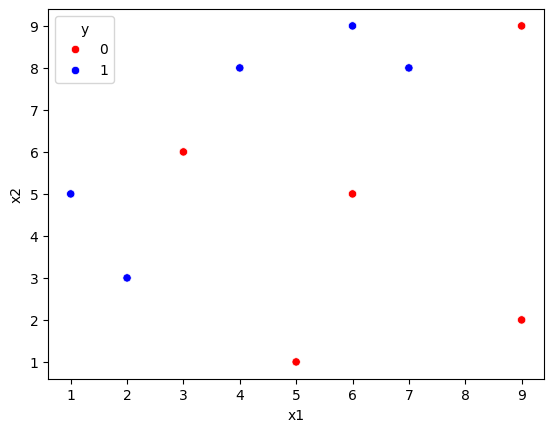

In [375]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
import seaborn as sns
sns.scatterplot(x=df['x1'], y=df['x2'], hue=df['y'] , palette=['red', 'blue'])

In [376]:
df['weights'] = 1/df.shape[0]

In [377]:
df

,x1,x2,y,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

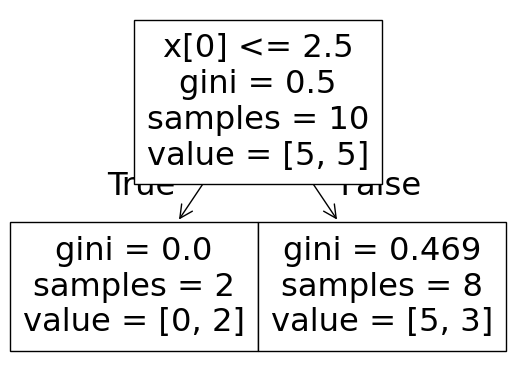

In [378]:
plot_tree(clf)

<Axes: >

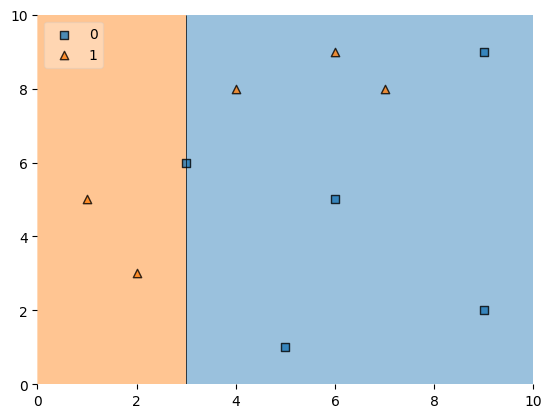

In [379]:
plot_decision_regions(x, y, clf=clf, legend=2)

In [380]:
df['y_pred'] = clf.predict(x)

In [381]:
df

,x1,x2,y,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [382]:
def calculate_error(error):
    return 0.5*np.log((1-error)/error)


In [383]:
#step-3 calculate model weight
alpha1 = calculate_error(0.3) #taking random number between 0 and 1
alpha1

np.float64(0.42364893019360184)

In [384]:
def update_weight(row , alpha1=0.3):
    if row['y'] == row['y_pred']:
        return row['weights']*np.exp(-alpha1)
    else:
        return row['weights']*np.exp(alpha1)

In [385]:
df['updated_weight'] = df.apply(update_weight , axis = 1)

In [386]:
df

,x1,x2,y,weights,y_pred,updated_weight
0,1,5,1,0.1,1,0.074082
1,2,3,1,0.1,1,0.074082
2,3,6,0,0.1,0,0.074082
3,4,8,1,0.1,0,0.134986
4,5,1,0,0.1,0,0.074082
5,6,9,1,0.1,0,0.134986
6,6,5,0,0.1,0,0.074082
7,7,8,1,0.1,0,0.134986
8,9,9,0,0.1,0,0.074082
9,9,2,0,0.1,0,0.074082


In [387]:
sum = df['updated_weight'].sum()

In [388]:
#step-4: Normalization
def normalize(row):
    return row['updated_weight']/sum

In [389]:
df['normalized_weight'] = df.apply(normalize , axis=1)

In [390]:
df

,x1,x2,y,weights,y_pred,updated_weight,normalized_weight
0,1,5,1,0.1,1,0.074082,0.080216
1,2,3,1,0.1,1,0.074082,0.080216
2,3,6,0,0.1,0,0.074082,0.080216
3,4,8,1,0.1,0,0.134986,0.146163
4,5,1,0,0.1,0,0.074082,0.080216
5,6,9,1,0.1,0,0.134986,0.146163
6,6,5,0,0.1,0,0.074082,0.080216
7,7,8,1,0.1,0,0.134986,0.146163
8,9,9,0,0.1,0,0.074082,0.080216
9,9,2,0,0.1,0,0.074082,0.080216


In [391]:
df['normalized_weight'].sum()

np.float64(1.0)

In [392]:
df['cumsum_upper'] = np.cumsum(df['normalized_weight'])
df['cumsum_lower'] = df['cumsum_upper'] -  np.cumsum(df['normalized_weight'])

In [393]:
df

,x1,x2,y,weights,y_pred,updated_weight,normalized_weight,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.074082,0.080216,0.080216,0.0
1,2,3,1,0.1,1,0.074082,0.080216,0.160432,0.0
2,3,6,0,0.1,0,0.074082,0.080216,0.240648,0.0
3,4,8,1,0.1,0,0.134986,0.146163,0.386811,0.0
4,5,1,0,0.1,0,0.074082,0.080216,0.467027,0.0
5,6,9,1,0.1,0,0.134986,0.146163,0.613189,0.0
6,6,5,0,0.1,0,0.074082,0.080216,0.693405,0.0
7,7,8,1,0.1,0,0.134986,0.146163,0.839568,0.0
8,9,9,0,0.1,0,0.074082,0.080216,0.919784,0.0
9,9,2,0,0.1,0,0.074082,0.080216,1.000000,0.0


In [394]:
def create_new_dataset(df):
    indices = []
    for i in range(df.shape[0]):
        a = np.random.random()
        for index , row in df.iterrows():
            if row['cumsum_upper'] > a and a> row['cumsum_lower']:
                indices.append(index)
    return indices


In [395]:
index_values = create_new_dataset(df)

In [396]:
index_values

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 4,
 5,
 6,
 7,
 8,
 9,
 7,
 8,
 9,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 6,
 7,
 8,
 9,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9]

In [397]:

second_df = df.iloc[index_values, [0,1,2,3]]

In [398]:
second_df

,x1,x2,y,weights
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
...,...,...,...,...
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1


In [399]:

X = second_df.iloc[:, 0:2].values
y = second_df.iloc[:, 2].values

In [400]:

clf2 = DecisionTreeClassifier(max_depth=1)
clf2.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


<Axes: >

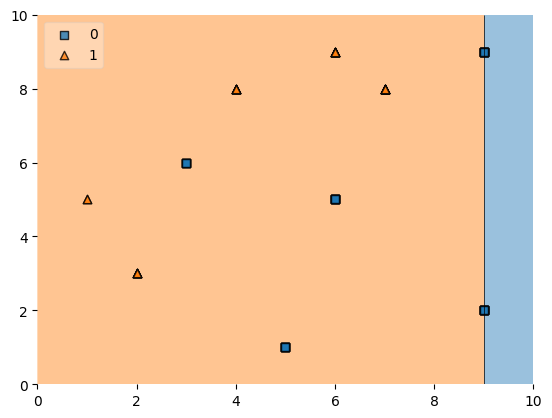

In [401]:
plot_decision_regions(X, y, clf=clf2, legend=2)

In [402]:

second_df['y_pred'] = clf2.predict(X)

In [403]:
second_df

,x1,x2,y,weights,y_pred
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,1
5,6,9,1,0.1,1
...,...,...,...,...,...
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,0


In [404]:
alpha2 = calculate_error(0.1)
alpha2

np.float64(1.0986122886681098)

In [405]:
# Step 4 - Update weights
def update_row_weights(row, alpha=1.09):
  if row['y'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [406]:

second_df['updated_weight'] = second_df.apply(update_row_weights, axis=1)

In [407]:
second_df

,x1,x2,y,weights,y_pred,updated_weight
1,2,3,1,0.1,1,0.033622
2,3,6,0,0.1,1,0.297427
3,4,8,1,0.1,1,0.033622
4,5,1,0,0.1,1,0.297427
5,6,9,1,0.1,1,0.033622
...,...,...,...,...,...,...
5,6,9,1,0.1,1,0.033622
6,6,5,0,0.1,1,0.297427
7,7,8,1,0.1,1,0.033622
8,9,9,0,0.1,0,0.033622


In [411]:
# Recompute normalization using the second_df weights only
second_sum = second_df['updated_weight'].sum()
second_df['normalize_weight'] = second_df['updated_weight'] / second_sum

In [409]:
second_df   

,x1,x2,y,weights,y_pred,updated_weight,normalize_weight
1,2,3,1,0.1,1,0.033622,0.036406
2,3,6,0,0.1,1,0.297427,0.322055
3,4,8,1,0.1,1,0.033622,0.036406
4,5,1,0,0.1,1,0.297427,0.322055
5,6,9,1,0.1,1,0.033622,0.036406
...,...,...,...,...,...,...,...
5,6,9,1,0.1,1,0.033622,0.036406
6,6,5,0,0.1,1,0.297427,0.322055
7,7,8,1,0.1,1,0.033622,0.036406
8,9,9,0,0.1,0,0.033622,0.036406


In [412]:
second_df['normalize_weight'].sum()

np.float64(0.9999999999999999)

In [415]:

second_df['cumsum_upper'] = np.cumsum(second_df['normalize_weight'])

In [416]:

second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['normalize_weight']

In [417]:
second_df

,x1,x2,y,weights,y_pred,updated_weight,normalize_weight,cumsum_upper,cumsum_lower
1,2,3,1,0.1,1,0.033622,0.003899,0.003899,0.000000
2,3,6,0,0.1,1,0.297427,0.034493,0.038392,0.003899
3,4,8,1,0.1,1,0.033622,0.003899,0.042292,0.038392
4,5,1,0,0.1,1,0.297427,0.034493,0.076785,0.042292
5,6,9,1,0.1,1,0.033622,0.003899,0.080684,0.076785
...,...,...,...,...,...,...,...,...,...
5,6,9,1,0.1,1,0.033622,0.003899,0.953809,0.949910
6,6,5,0,0.1,1,0.297427,0.034493,0.988302,0.953809
7,7,8,1,0.1,1,0.033622,0.003899,0.992202,0.988302
8,9,9,0,0.1,0,0.033622,0.003899,0.996101,0.992202


In [418]:
index_values = create_new_dataset(second_df)

In [419]:

third_df = second_df.iloc[index_values, [0,1,2,3]]

In [420]:

third_df

,x1,x2,y,weights
3,4,8,1,0.1
7,7,8,1,0.1
5,6,9,1,0.1
5,6,9,1,0.1
7,7,8,1,0.1
...,...,...,...,...
8,9,9,0,0.1
3,4,8,1,0.1
7,7,8,1,0.1
5,6,9,1,0.1


In [421]:
clf3 = DecisionTreeClassifier(max_depth=1)

X = second_df.iloc[:, 0:2].values
y = second_df.iloc[:, 2].values

clf3.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


<Axes: >

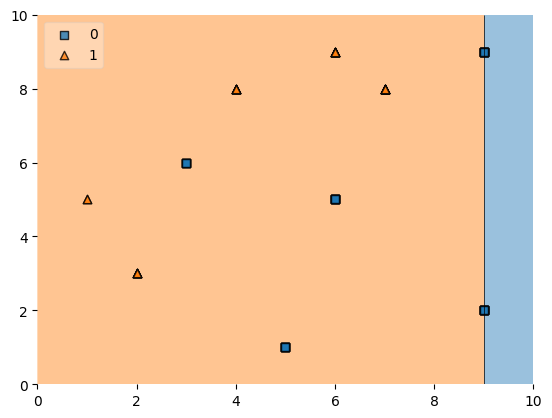

In [422]:

plot_decision_regions(X, y, clf=clf3, legend=2)

In [424]:


third_df['y_pred'] = clf3.predict(X)

In [426]:

alpha3 = calculate_error(0.7)
alpha3

np.float64(-0.4236489301936017)

In [427]:
print(alpha1, alpha2,alpha3)

0.42364893019360184 1.0986122886681098 -0.4236489301936017


### Prediction

In [428]:

query = np.array([1, 5]).reshape(1, 2)
clf.predict(query)

array([1])

In [429]:
clf2.predict(query)

array([1])

In [435]:
clf3.predict(query)

array([0])

In [431]:

alpha1*1 + alpha2*(1) + alpha3*(1)

np.float64(1.09861228866811)

In [432]:
np.sign(1.09)

np.float64(1.0)

In [ ]:
query = np.array([9, 9]).reshape(1, 2)
clf.predict(query)

array([0])

In [434]:
clf2.predict(query)

array([0])

In [436]:
clf3.predict(query)

array([0])

In [437]:

alpha1*(-1) + alpha2*(-1) + alpha3*(-1)

np.float64(-1.09861228866811)

In [439]:

np.sign(-1.09)

np.float64(-1.0)